In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Ajustando a base

In [59]:
df = pd.read_csv('../data/credit_risk_dataset.csv')
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [60]:
variable_mapping = {
    'person_age': 'idade_individuo',
    'person_income': 'renda_anual_individuo',
    'person_home_ownership': 'tipo_posse_imovel',
    'person_emp_length': 'tempo_emprego_anos',
    'loan_intent': 'proposito_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_emprestimo',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'duracao_historico_credito'
}
df.rename(columns=variable_mapping, inplace=True)
variable_mapping


{'person_age': 'idade_individuo',
 'person_income': 'renda_anual_individuo',
 'person_home_ownership': 'tipo_posse_imovel',
 'person_emp_length': 'tempo_emprego_anos',
 'loan_intent': 'proposito_emprestimo',
 'loan_grade': 'classificacao_emprestimo',
 'loan_amnt': 'valor_emprestimo',
 'loan_int_rate': 'taxa_juros_emprestimo',
 'loan_status': 'status_emprestimo',
 'loan_percent_income': 'percentual_renda_emprestimo',
 'cb_person_default_on_file': 'historico_inadimplencia',
 'cb_person_cred_hist_length': 'duracao_historico_credito'}

In [61]:
# Traduzindo e substituindo as categorias da variável tipo_posse_imovel
mapeamento_categorias_imovel = {
    'RENT': 'aluguel',
    'OWN': 'imovel_proprio',
    'MORTGAGE': 'imovel_financiado',
    'OTHER': 'imovel_outros'
}

df['tipo_posse_imovel'] = df['tipo_posse_imovel'].replace(mapeamento_categorias_imovel)

In [62]:
df['tipo_posse_imovel'].value_counts()

tipo_posse_imovel
aluguel              16446
imovel_financiado    13444
imovel_proprio        2584
imovel_outros          107
Name: count, dtype: int64

In [63]:
# Traduzindo e substituindo as categorias da variável proposito_emprestimo
mapeamento_categorias_proposito = {
    'DEBTCONSOLIDATION': 'fins_consolidacao_debito',
    'EDUCATION': 'fins_educacao',
    'MEDICAL': 'fins_medicos',
    'PERSONAL': 'fins_pessoais',
    'VENTURE': 'fins_negocios',
    'HOMEIMPROVEMENT': 'fins_reformas'
}



df['proposito_emprestimo'] = df['proposito_emprestimo'].replace(mapeamento_categorias_proposito)
df['proposito_emprestimo'].value_counts()

proposito_emprestimo
fins_educacao               6453
fins_medicos                6071
fins_negocios               5719
fins_pessoais               5521
fins_consolidacao_debito    5212
fins_reformas               3605
Name: count, dtype: int64

In [64]:
dict_hist = {
    'N': 'N',
    'Y': 'S'
}

print(df['historico_inadimplencia'].value_counts())
df['historico_inadimplencia'] = df['historico_inadimplencia'].replace(dict_hist)
print(df['historico_inadimplencia'].value_counts())

historico_inadimplencia
N    26836
Y     5745
Name: count, dtype: int64
historico_inadimplencia
N    26836
S     5745
Name: count, dtype: int64


In [65]:
df.head()

,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


## Analise Exploratoria de Dados (somente vars utilizadas)

In [66]:
df = df.reset_index()
df.rename(columns={'index': 'id'}, inplace=True)
df.head()

,id,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


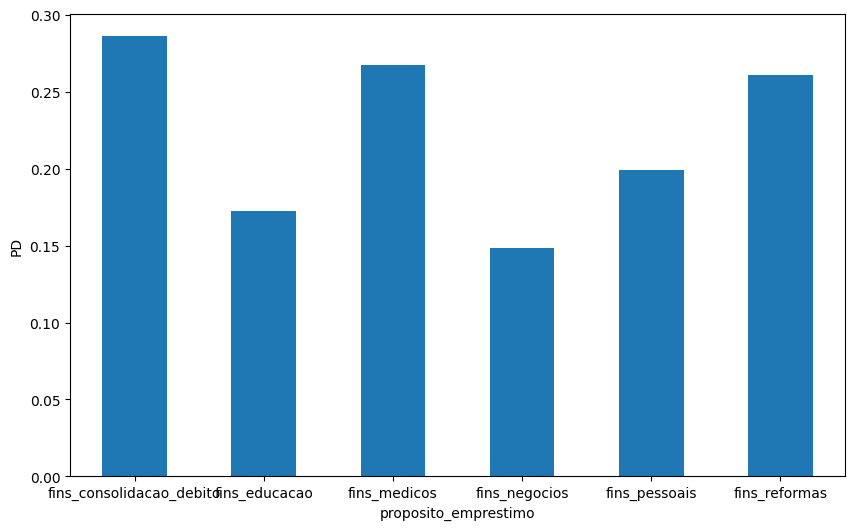

In [67]:
df_agp = df.groupby('proposito_emprestimo').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='proposito_emprestimo', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

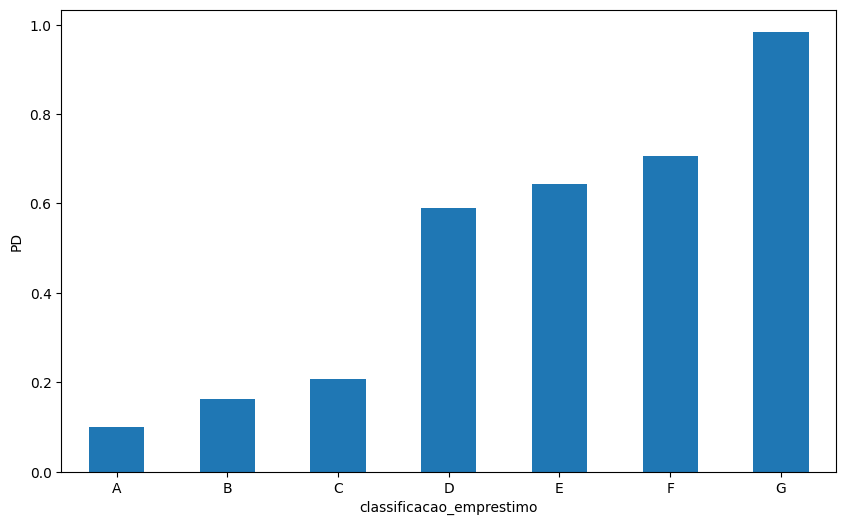

In [68]:
df_agp = df.groupby('classificacao_emprestimo').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='classificacao_emprestimo', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

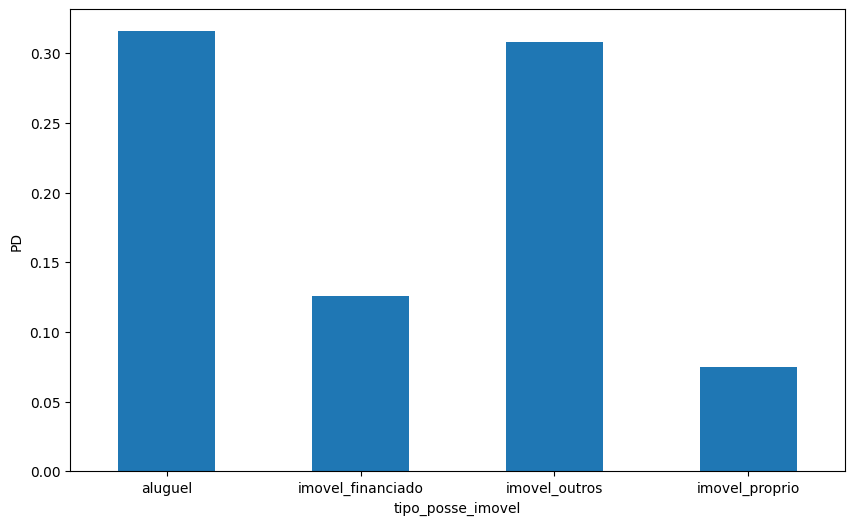

In [69]:
df_agp = df.groupby('tipo_posse_imovel').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='tipo_posse_imovel', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

In [70]:
# Como está a correlação com variável resposta? 
colunas_quantitativas = ['status_emprestimo', 'idade_individuo', 'renda_anual_individuo', 'tempo_emprego_anos', 
                         'valor_emprestimo', 'taxa_juros_emprestimo', 'percentual_renda_emprestimo',
                         'duracao_historico_credito']
df[colunas_quantitativas].corr(method='pearson')

,status_emprestimo,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
status_emprestimo,1.000000,-0.021629,-0.144449,-0.082489,0.105376,0.335133,0.379366,-0.015529
idade_individuo,-0.021629,1.000000,0.173202,0.163106,0.050787,0.012580,-0.042411,0.859133
renda_anual_individuo,-0.144449,0.173202,1.000000,0.134268,0.266820,0.000792,-0.254471,0.117987
tempo_emprego_anos,-0.082489,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.054111,0.144699
valor_emprestimo,0.105376,0.050787,0.266820,0.113082,1.000000,0.146813,0.572612,0.041967
taxa_juros_emprestimo,0.335133,0.012580,0.000792,-0.056405,0.146813,1.000000,0.120314,0.016696
percentual_renda_emprestimo,0.379366,-0.042411,-0.254471,-0.054111,0.572612,0.120314,1.000000,-0.031690
duracao_historico_credito,-0.015529,0.859133,0.117987,0.144699,0.041967,0.016696,-0.031690,1.000000


In [71]:
# Dropando as colunas nulas (opção de modelagem)
print(df.shape)
print(df.isnull().sum())
df = df.drop(columns=['tempo_emprego_anos', 'taxa_juros_emprestimo'])
print(df.shape)

(32581, 13)
id                                0
idade_individuo                   0
renda_anual_individuo             0
tipo_posse_imovel                 0
tempo_emprego_anos              895
proposito_emprestimo              0
classificacao_emprestimo          0
valor_emprestimo                  0
taxa_juros_emprestimo          3116
status_emprestimo                 0
percentual_renda_emprestimo       0
historico_inadimplencia           0
duracao_historico_credito         0
dtype: int64
(32581, 11)


In [72]:
# Deixando apenas observações menores que 80 anos de idade
print(df.shape)
df = df.loc[df['idade_individuo'] <= 80]
print(df.shape)

(32581, 11)
(32574, 11)


## Fazendo One Hot Encoder

In [73]:
df.info()

<class 'pandas.DataFrame'>
Index: 32574 entries, 0 to 32580
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           32574 non-null  int64  
 1   idade_individuo              32574 non-null  int64  
 2   renda_anual_individuo        32574 non-null  int64  
 3   tipo_posse_imovel            32574 non-null  str    
 4   proposito_emprestimo         32574 non-null  str    
 5   classificacao_emprestimo     32574 non-null  str    
 6   valor_emprestimo             32574 non-null  int64  
 7   status_emprestimo            32574 non-null  int64  
 8   percentual_renda_emprestimo  32574 non-null  float64
 9   historico_inadimplencia      32574 non-null  str    
 10  duracao_historico_credito    32574 non-null  int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 3.0 MB


In [74]:
df = df.drop(columns='id').reset_index(drop=True)
print(df.shape)
df.head()

(32574, 10)


,idade_individuo,renda_anual_individuo,tipo_posse_imovel,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,fins_pessoais,D,35000,1,0.59,S,3
1,21,9600,imovel_proprio,fins_educacao,B,1000,0,0.10,N,2
2,25,9600,imovel_financiado,fins_medicos,C,5500,1,0.57,N,3
3,23,65500,aluguel,fins_medicos,C,35000,1,0.53,N,2
4,24,54400,aluguel,fins_medicos,C,35000,1,0.55,S,4


In [75]:
colunas_quantitativas = ['idade_individuo', 'renda_anual_individuo',  
                         'valor_emprestimo',
                         'percentual_renda_emprestimo','duracao_historico_credito']

# Removendo historico_inadimplencia para corrigir bug
colunas_categoricas = ['tipo_posse_imovel', 'proposito_emprestimo','classificacao_emprestimo', 
                       #'historico_inadimplencia'
                       ]

var_resposta = ['status_emprestimo']

In [76]:
# Dropando a primeira categoria de cada variavel para utilizar como referência
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
x_cat = ohe.fit_transform(df[colunas_categoricas])
nomes_colunas = ohe.get_feature_names_out(colunas_categoricas)

In [77]:
x_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(32574, 14))

In [78]:
nomes_colunas

array(['tipo_posse_imovel_imovel_financiado',
       'tipo_posse_imovel_imovel_outros',
       'tipo_posse_imovel_imovel_proprio',
       'proposito_emprestimo_fins_educacao',
       'proposito_emprestimo_fins_medicos',
       'proposito_emprestimo_fins_negocios',
       'proposito_emprestimo_fins_pessoais',
       'proposito_emprestimo_fins_reformas', 'classificacao_emprestimo_B',
       'classificacao_emprestimo_C', 'classificacao_emprestimo_D',
       'classificacao_emprestimo_E', 'classificacao_emprestimo_F',
       'classificacao_emprestimo_G'], dtype=object)

In [79]:
df_cat = pd.DataFrame(x_cat, columns=nomes_colunas, index=df.index)
df_cat

,tipo_posse_imovel_imovel_financiado,tipo_posse_imovel_imovel_outros,tipo_posse_imovel_imovel_proprio,proposito_emprestimo_fins_educacao,proposito_emprestimo_fins_medicos,proposito_emprestimo_fins_negocios,proposito_emprestimo_fins_pessoais,proposito_emprestimo_fins_reformas,classificacao_emprestimo_B,classificacao_emprestimo_C,classificacao_emprestimo_D,classificacao_emprestimo_E,classificacao_emprestimo_F,classificacao_emprestimo_G
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32569,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32570,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
32572,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [80]:
print(df.shape)
df = pd.concat([df, df_cat], axis=1)
print(df.shape)
df = df.drop(colunas_categoricas, axis=1)
print(df.shape)

(32574, 10)
(32574, 24)
(32574, 21)


In [81]:
# Como ficou?
pd.set_option('display.max_columns', None)
df.head()

,idade_individuo,renda_anual_individuo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito,tipo_posse_imovel_imovel_financiado,tipo_posse_imovel_imovel_outros,tipo_posse_imovel_imovel_proprio,proposito_emprestimo_fins_educacao,proposito_emprestimo_fins_medicos,proposito_emprestimo_fins_negocios,proposito_emprestimo_fins_pessoais,proposito_emprestimo_fins_reformas,classificacao_emprestimo_B,classificacao_emprestimo_C,classificacao_emprestimo_D,classificacao_emprestimo_E,classificacao_emprestimo_F,classificacao_emprestimo_G
0,22,59000,35000,1,0.59,S,3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,21,9600,1000,0,0.10,N,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,25,9600,5500,1,0.57,N,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,23,65500,35000,1,0.53,N,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,24,54400,35000,1,0.55,S,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Binning

### Renda anual

In [82]:
from optbinning import OptimalBinning
var_bin = 'renda_anual_individuo'
x_bin = df[var_bin]
y_bin = df['status_emprestimo']

optb_renda = OptimalBinning(name=var_bin, dtype="numerical", prebinning_method='cart')
optb_renda.fit(x_bin, y_bin)

,name,'renda_anual_individuo'
,dtype,'numerical'
,prebinning_method,'cart'
,solver,'cp'
,divergence,'iv'
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None


In [83]:
print(optb_renda.splits)
binning_table = optb_renda.binning_table
binning_table.build()

[22882.  34999.5 39937.5 49994.  59982.  79993.5 89325. ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 22882.00)",1630,0.050040,597,1033,0.633742,-1.824429,0.222373,0.024487
1,"[22882.00, 34999.50)",4590,0.140910,2821,1769,0.385403,-0.809446,0.111784,0.013604
2,"[34999.50, 39937.50)",2304,0.070731,1694,610,0.264757,-0.254734,0.004916,0.000613
3,"[39937.50, 49994.00)",4778,0.146681,3751,1027,0.214943,0.019257,0.000054,0.000007
4,"[49994.00, 59982.00)",4377,0.134371,3475,902,0.206077,0.072612,0.000694,0.000087
5,"[59982.00, 79993.50)",6800,0.208755,5767,1033,0.151912,0.443562,0.035986,0.004462
6,"[79993.50, 89325.00)",1975,0.060631,1772,203,0.102785,0.890535,0.036533,0.004421
7,"[89325.00, inf)",6120,0.187880,5589,531,0.086765,1.07767,0.156008,0.018609
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


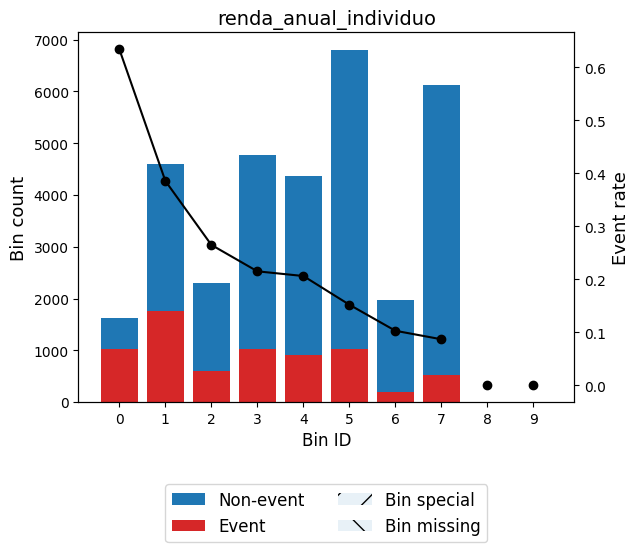

In [84]:
binning_table.plot(metric='event_rate')

In [85]:
nome_ajustado = f'{var_bin}_woe'
df[nome_ajustado] = optb_renda.transform(df[var_bin], metric='woe')
df[[var_bin, nome_ajustado]].head()

,renda_anual_individuo,renda_anual_individuo_woe
0,59000,0.072612
1,9600,-1.824429
2,9600,-1.824429
3,65500,0.443562
4,54400,0.072612


### Valor emprestimo

In [86]:
from optbinning import OptimalBinning
var_bin = 'valor_emprestimo'
x_bin = df[var_bin]
y_bin = df['status_emprestimo']

optb_valor = OptimalBinning(name=var_bin, dtype="numerical", prebinning_method='cart', monotonic_trend='ascending')
optb_valor.fit(x_bin, y_bin)

,name,'valor_emprestimo'
,dtype,'numerical'
,prebinning_method,'cart'
,solver,'cp'
,divergence,'iv'
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None


In [87]:
print(optb_valor.splits)
binning_table = optb_valor.binning_table
binning_table.build()

[ 8262.5 10587.5 14487.5 18087.5 22150. ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 8262.50)",16860,0.517591,13694,3166,0.187782,0.188366,1.739046e-02,2.170600e-03
1,"[8262.50, 10587.50)",4892,0.150181,3919,973,0.198896,0.117084,1.990839e-03,2.487128e-04
2,"[10587.50, 14487.50)",4251,0.130503,3324,927,0.218066,0.000847,9.366160e-08,1.170770e-08
3,"[14487.50, 18087.50)",3140,0.096396,2285,855,0.272293,-0.293103,8.957102e-03,1.115647e-03
4,"[18087.50, 22150.00)",1656,0.050838,1118,538,0.324879,-0.544685,1.731429e-02,2.137922e-03
5,"[22150.00, inf)",1775,0.054491,1126,649,0.365634,-0.725129,3.414616e-02,4.177148e-03
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
Totals,,32574,1.000000,25466,7108,0.218211,,7.979894e-02,9.850041e-03


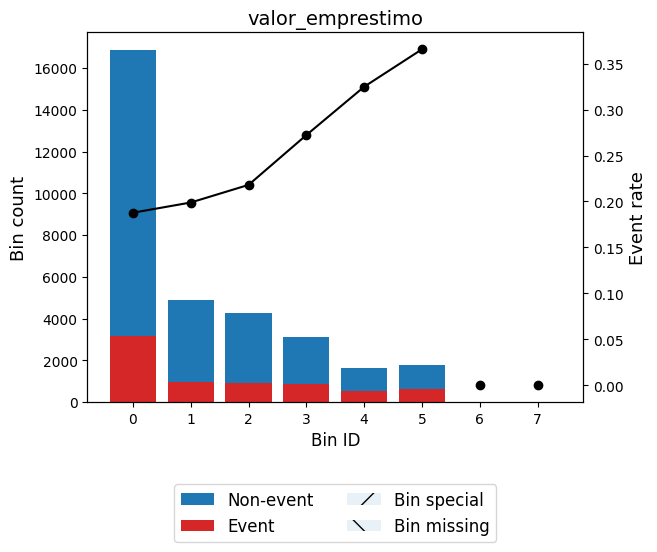

In [88]:
binning_table.plot(metric='event_rate')

In [89]:
nome_ajustado = f'{var_bin}_woe'
df[nome_ajustado] = optb_valor.transform(df[var_bin], metric='woe')
df[[var_bin, nome_ajustado]].head()

,valor_emprestimo,valor_emprestimo_woe
0,35000,-0.725129
1,1000,0.188366
2,5500,0.188366
3,35000,-0.725129
4,35000,-0.725129


## Modelo de Regressão Logística

In [90]:
print(df.shape)
Y = df['status_emprestimo']
print(Y.shape)
X = df.drop(columns='status_emprestimo')
print(X.shape)

(32574, 23)
(32574,)
(32574, 22)


In [91]:
# Selecionando aqui somente as variáveis de interesse com base no teste de significância
colunas_rodar = [
#'idade_individuo', 
#'renda_anual_individuo',
'renda_anual_individuo_woe',
#'valor_emprestimo',
'valor_emprestimo_woe',
'percentual_renda_emprestimo',
#'duracao_historico_credito',
'tipo_posse_imovel_imovel_financiado',
#'tipo_posse_imovel_imovel_outros', 
'tipo_posse_imovel_imovel_proprio',
'proposito_emprestimo_fins_educacao',
'proposito_emprestimo_fins_medicos',
'proposito_emprestimo_fins_negocios',
'proposito_emprestimo_fins_pessoais',
#'proposito_emprestimo_fins_reformas',
'classificacao_emprestimo_B',
'classificacao_emprestimo_C', 
'classificacao_emprestimo_D',
'classificacao_emprestimo_E', 
'classificacao_emprestimo_F',
'classificacao_emprestimo_G',
#'historico_inadimplencia_S'
]
print(X.shape)
X = X[colunas_rodar]
print(X.shape)

(32574, 22)
(32574, 15)


In [92]:
# Utilizando o statsmodels para ver as métricas estatísticas
import statsmodels.api as sm

X_const = sm.add_constant(X)
model_stats = sm.Logit(Y, X_const)

result = model_stats.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.330562
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      status_emprestimo   No. Observations:                32574
Model:                          Logit   Df Residuals:                    32558
Method:                           MLE   Df Model:                           15
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.3699
Time:                        18:15:33   Log-Likelihood:                -10768.
converged:                       True   LL-Null:                       -17089.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -2.6614      0.067 

In [93]:
# Quais são os valores de woe?
print(df['renda_anual_individuo_woe'].value_counts())
print(df['valor_emprestimo_woe'].value_counts())

renda_anual_individuo_woe
 0.443562    6800
 1.077670    6120
 0.019257    4778
-0.809446    4590
 0.072612    4377
-0.254734    2304
 0.890535    1975
-1.824429    1630
Name: count, dtype: int64
valor_emprestimo_woe
 0.188366    16860
 0.117084     4892
 0.000847     4251
-0.293103     3140
-0.725129     1775
-0.544685     1656
Name: count, dtype: int64


In [94]:
# Os coeficientes do statsmodels e sklearn são semelhantes
# Vou seguir com sklearn
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X, Y)

y_prob = model.predict_proba(X)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [95]:
import joblib
joblib.dump(model, "../artifacts/modelo_pd_rl.pkl")
joblib.dump(X.columns.to_list(), '../artifacts/colunas_modelo.pkl')


['../artifacts/colunas_modelo.pkl']

In [96]:
bins_woe = {
    "renda_anual_individuo": optb_renda,
    "valor_emprestimo": optb_valor
}
joblib.dump(bins_woe, "../artifacts/bins_woe.pkl")

['../artifacts/bins_woe.pkl']

In [97]:
# Salvando o encoder
joblib.dump(ohe, "../artifacts/encoder_ohe.pkl")

['../artifacts/encoder_ohe.pkl']

In [108]:
metadata = {
    "features_numericas": [
        "percentual_renda_emprestimo"
    ],
    "features_categoricas": [
        "tipo_posse_imovel",
        "proposito_emprestimo",
        "classificacao_emprestimo"
    ],
    "features_woe": [
        "renda_anual_individuo",
        "valor_emprestimo"
    ]
}

joblib.dump(metadata, "../artifacts/metadata.pkl")

['../artifacts/metadata.pkl']

## Métricas do Modelo

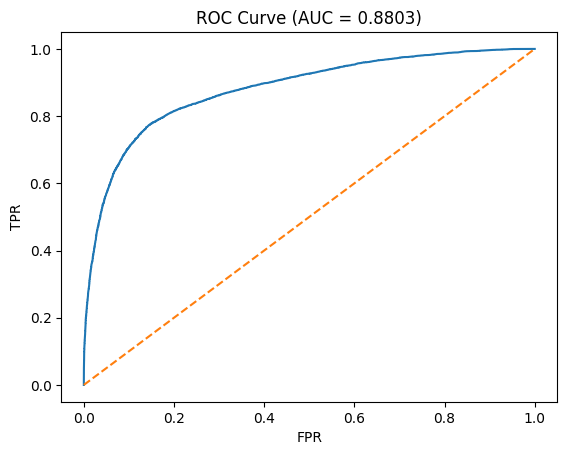

AUC: 0.8802622576071173


In [99]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(Y, y_prob)
auc = roc_auc_score(Y, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC Curve (AUC = {auc:.4f})')
plt.show()

print("AUC:", auc)

In [100]:
gini = 2 * auc - 1
print("GINI:", gini)

GINI: 0.7605245152142346


In [101]:
df_ks = pd.DataFrame({
    'y': Y,
    'prob': y_prob
})

df_ks = df_ks.sort_values('prob')

df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
df_ks['cum_bad'] = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()

df_ks['ks'] = abs(df_ks['cum_bad'] - df_ks['cum_good'])

ks = df_ks['ks'].max()

print("KS:", ks)

KS: 0.6292761231157692


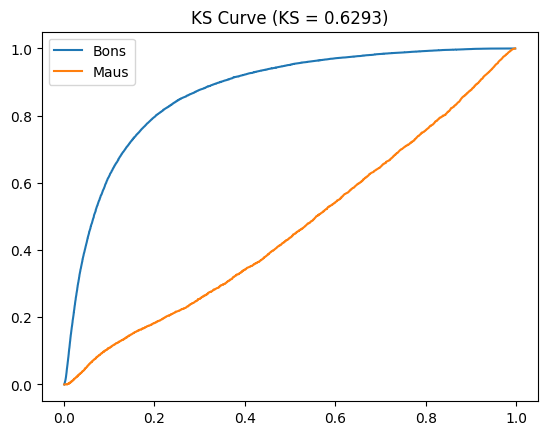

In [102]:
plt.plot(df_ks['prob'], df_ks['cum_good'], label='Bons')
plt.plot(df_ks['prob'], df_ks['cum_bad'], label='Maus')
plt.legend()
plt.title(f'KS Curve (KS = {ks:.4f})')
plt.show()

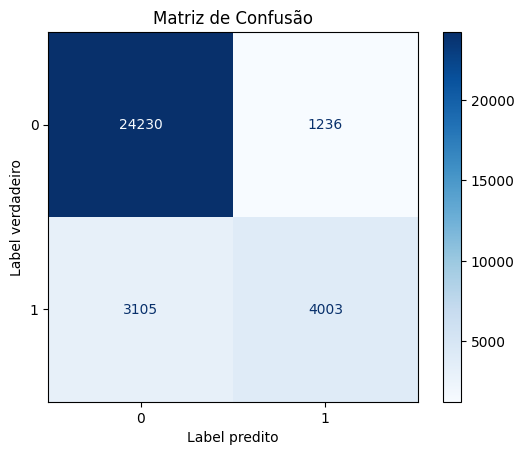

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    Y,
    y_pred,
    cmap='Blues',
    values_format='d'  # mostra inteiros
)

plt.title("Matriz de Confusão")
plt.ylabel("Label verdadeiro")
plt.xlabel("Label predito")
plt.show()

In [104]:
from sklearn.metrics import classification_report

print(classification_report(Y, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     25466
           1       0.76      0.56      0.65      7108

    accuracy                           0.87     32574
   macro avg       0.83      0.76      0.78     32574
weighted avg       0.86      0.87      0.86     32574



In [105]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(Y, y_prob)
print("Brier Score:", brier)

Brier Score: 0.09961700038054407


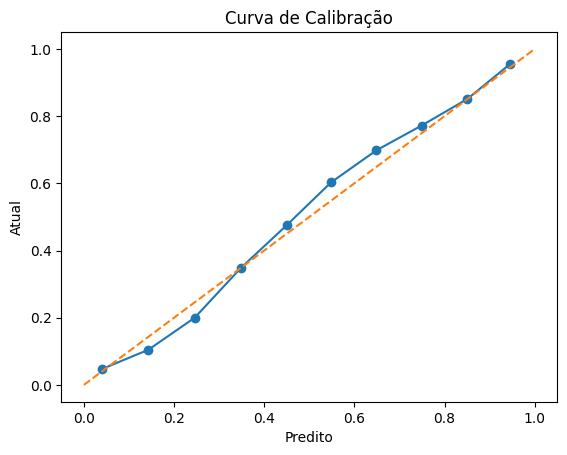

In [106]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(Y, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Atual')
plt.title('Curva de Calibração')
plt.show()

## Fazendo testes de previsão de PD

In [109]:
# Trazendo os artefatos do modelo
modelo_pd_rl = joblib.load("../artifacts/modelo_pd_rl.pkl")
colunas_modelo = joblib.load("../artifacts/colunas_modelo.pkl")
bins_woe = joblib.load("../artifacts/bins_woe.pkl")
encoder_ohe = joblib.load("../artifacts/encoder_ohe.pkl")

In [111]:
# Função para calcular a PD
def prever_pd(novo_cliente: dict) -> float:
    campos_necessarios = [
        "renda_anual_individuo",
        "valor_emprestimo",
        "percentual_renda_emprestimo",
        "tipo_posse_imovel",
        "proposito_emprestimo",
        "classificacao_emprestimo"
]

    faltando = [c for c in campos_necessarios if c not in novo_cliente]
    if faltando:
        raise ValueError(f"Campos ausentes: {faltando}")

    df = pd.DataFrame([novo_cliente])

    # WOE
    df["renda_anual_individuo_woe"] = bins_woe["renda_anual_individuo"].transform(
        df["renda_anual_individuo"], metric="woe"
    )

    df["valor_emprestimo_woe"] = bins_woe["valor_emprestimo"].transform(
        df["valor_emprestimo"], metric="woe"
    )

    # categóricas
    df_cat = df[[
        "tipo_posse_imovel",
        "proposito_emprestimo",
        "classificacao_emprestimo"
    ]]

    X_cat = encoder_ohe.transform(df_cat)

    df_ohe = pd.DataFrame(
        X_cat,
        columns=encoder_ohe.get_feature_names_out(df_cat.columns),
        index=df.index
    )

    # montar base final
    df_final = pd.concat(
        [
            df[[
                "renda_anual_individuo_woe",
                "valor_emprestimo_woe",
                "percentual_renda_emprestimo"
            ]],
            df_ohe
        ],
        axis=1
    )

    # alinhar colunas
    df_final = df_final.reindex(columns=colunas_modelo, fill_value=0)
    df_final = df_final.astype("float")

    # prever
    pd_prevista = modelo_pd_rl.predict_proba(df_final)[:, 1][0]

    return float(pd_prevista)

In [112]:
# Exemplo de chamada na API
cliente_json = {
    "renda_anual_individuo": 50000,
    "valor_emprestimo": 12000,
    "percentual_renda_emprestimo": 0.30,
    "tipo_posse_imovel": "imovel_proprio",
    "proposito_emprestimo": "fins_pessoais",
    "classificacao_emprestimo": "C"
}

pd_prevista = prever_pd(cliente_json)
print(f"PD prevista: {pd_prevista:.4%}")

PD prevista: 4.0703%


In [113]:
# Verificando os coeficientes do modelo
coefs = pd.DataFrame({
    "feature": colunas_modelo,
    "coef": model.coef_[0]
})

coefs = coefs.sort_values(by="coef", ascending=False)
print(coefs)
print(model.intercept_)

                                feature      coef
2           percentual_renda_emprestimo  6.388865
14           classificacao_emprestimo_G  5.101200
13           classificacao_emprestimo_F  3.345646
12           classificacao_emprestimo_E  3.103626
11           classificacao_emprestimo_D  2.849004
10           classificacao_emprestimo_C  0.688365
9            classificacao_emprestimo_B  0.336369
6     proposito_emprestimo_fins_medicos -0.213623
8    proposito_emprestimo_fins_pessoais -0.635422
3   tipo_posse_imovel_imovel_financiado -0.792330
5    proposito_emprestimo_fins_educacao -0.850984
1                  valor_emprestimo_woe -0.866970
0             renda_anual_individuo_woe -1.098474
7    proposito_emprestimo_fins_negocios -1.101036
4      tipo_posse_imovel_imovel_proprio -2.480138
[-2.5688641]


In [114]:
# Conferindo manualmente
woe_renda = bins_woe["renda_anual_individuo"].transform([50000], metric="woe")[0]
woe_valor = bins_woe["valor_emprestimo"].transform([12000], metric="woe")[0]

# logit
logit = (
    -2.5688641
    + (-1.098474 * woe_renda)
    + (-0.866970 * woe_valor)
    + (6.388865 * 0.30)
    + (-2.480138 * 1)  # imovel_proprio
    + (	-0.635422 * 1)  # fins_pessoais
    + (0.688365 * 1)   # classificacao_C
)

# PD
pd_manual = 1 / (1 + np.exp(-logit))

print("Logit:", logit)
print("PD manual:", pd_manual)

Logit: -3.159896464212923
PD manual: 0.0407030960742255


In [115]:
# Testando um caso mau
cliente_json = {
    "renda_anual_individuo": 50000,
    "valor_emprestimo": 12000,
    "percentual_renda_emprestimo": 0.30,
    "tipo_posse_imovel": "imovel_proprio",
    "proposito_emprestimo": "fins_pessoais",
    "classificacao_emprestimo": "G"
}

pd_prevista = prever_pd(cliente_json)
print(f"PD prevista: {pd_prevista:.4%}")

PD prevista: 77.7808%
